  Domain Code             Domain  Area Code         Area  Element Code  \
0          QL  Livestock Primary          2  Afghanistan          5322   
1          QL  Livestock Primary          2  Afghanistan          5322   
2          QL  Livestock Primary          2  Afghanistan          5322   
3          QL  Livestock Primary          2  Afghanistan          5322   
4          QL  Livestock Primary          2  Afghanistan          5322   

      Element  Item Code                     Item  Year Code  Year  Unit  \
0  Production        944  Meat indigenous, cattle       1961  1961  Head   
1  Production        944  Meat indigenous, cattle       1962  1962  Head   
2  Production        944  Meat indigenous, cattle       1963  1963  Head   
3  Production        944  Meat indigenous, cattle       1964  1964  Head   
4  Production        944  Meat indigenous, cattle       1965  1965  Head   

      Value Flag Flag Description  
0  360000.0    F     FAO estimate  
1  384000.0    F     FAO e

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_11848/893343041.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


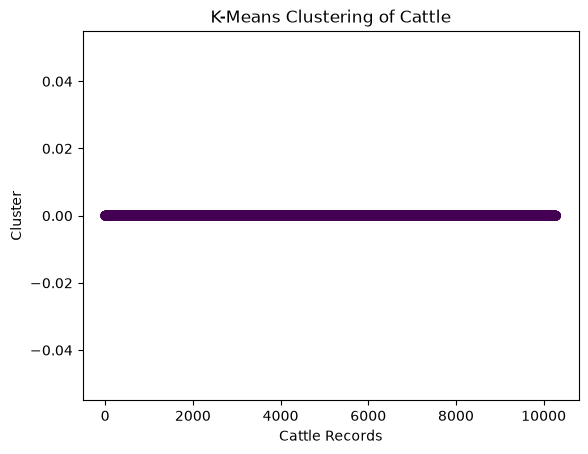


Saved as cattle_weight_clustered.csv


In [1]:
# Cattle Weight - NLP + K-Means

import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cattle_weight.csv")
print(df.head())
print(df.info())

# Find text column
text_col = df.select_dtypes(include="object").columns[0]

# NLP preprocessing
df["clean_text"] = df[text_col].astype(str).str.lower()
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"[^a-z\s]", "", x)
)

# Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["clean_text"])

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Show results
print("\nCluster Results:")
print(df[[text_col, "Cluster"]])

# Plot clusters
plt.scatter(range(len(df)), df["Cluster"], c=df["Cluster"])
plt.xlabel("Cattle Records")
plt.ylabel("Cluster")
plt.title("K-Means Clustering of Cattle")
plt.show()

# Save result
df.to_csv("cattle_weight_clustered.csv", index=False)
print("\nSaved as cattle_weight_clustered.csv")